#### 6.3 绘制动态图表
##### 1. 分析产品走势

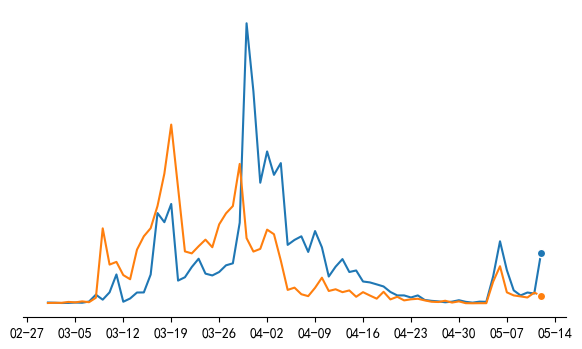

In [1]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.dates as mdates # 导入日期模块
import pandas as pd

# 1. 数据准备
# 读取Excel文件
df=pd.read_excel("data6.xlsx")
# 解决中文乱码
plt.rcParams['font.sans-serif']=['SimHei']

# 2. 设置画布
fig = plt.figure(figsize=(7, 4))
# 设置x轴数据
x = df['日期']
# 设置第一个y轴和第二个y轴数据
y1, y2 =df['产品1'], df['产品2']

# 3.绘制动态图表
# 创建子图返回坐标轴对象axes
ax = plt.subplot()
# 第一个y轴折线图
(line1,) = ax.plot(x, y1,   # xy轴数据
                   marker="o", # 标记
                   markevery=[-1], # 设置每个点只显示一个标记
                   markeredgecolor="white")  # 标记边的颜色
# 第二个y轴折线图
(line2,) = ax.plot(x, y2, marker="o",markevery=[-1], markeredgecolor="white")
# 设置注释文本（在日期所在的位置显示数据）
text1 = ax.text(x[0],y1[0], '', ha="left", va="top")
text2 = ax.text(x[0],y2[0], '', ha="left", va="top")
# 设置x坐标轴刻度为x
ax.set_xticks(x)
# 设置y坐标轴刻度为空
ax.set_yticks([])
# 设置连接坐标轴刻度的线不可见
# spines是连接坐标轴刻度的线
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
# 日期显示格式为月日
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# 日期刻度定位为星期
ax.xaxis.set_major_locator(mdates.WeekdayLocator())

# 自定义更新函数update
def update(frame):
    line1.set_data(x[:frame+1], y1[:frame+1])
    line2.set_data(x[:frame+1], y2[:frame+1])
    text1.set_position((x[frame], y1[frame]))
    text1.set_text(f'产品1: {y1[frame]}')
    text2.set_position((x[frame], y2[frame]))
    text2.set_text(f'产品2: {y2[frame]}')
    return line1,line2

# 执行动画
ani = animation.FuncAnimation(fig, update, interval=100,frames=len(x))
# 显示图表
plt.show()
# 将动画保存为.gif格式
ani.save('myline.gif',writer='pillow',fps=100)

##### 2. Animation 小动画

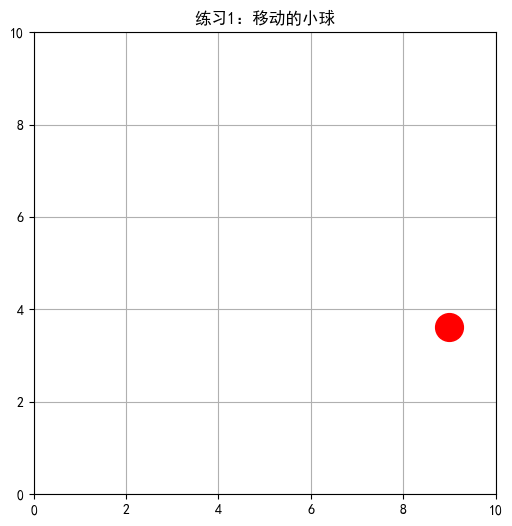

In [ ]:
# 1. 移动的小球
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文显示问题
# 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')  # 保持纵横比一致
ax.grid(True)  # 显示网格线

# 创建一个小球
ball, = ax.plot([], [], 'o', markersize=20, color='red')

# 动画初始化函数，用于设置初始状态
def init():
    ball.set_data([], [])  # 设置小球的位置为空（初始位置）
    return ball,

# 更新函数
def update(frame):
    x = frame % 10                      # 小球在 x 轴上的位置，循环移动
    y = 5 + 3 * np.sin(frame * 0.1)     # 小球在 y 轴上做正弦运动
    ball.set_data([x], [y])  # 设置小球的新位置
    return ball,

# 创建动画
ani = FuncAnimation(fig, update, frames=100, init_func=init, blit=True, interval=50)
plt.title('练习1：移动的小球')
# plt.show()
ani.save("ball.gif", writer="pillow", fps=25)

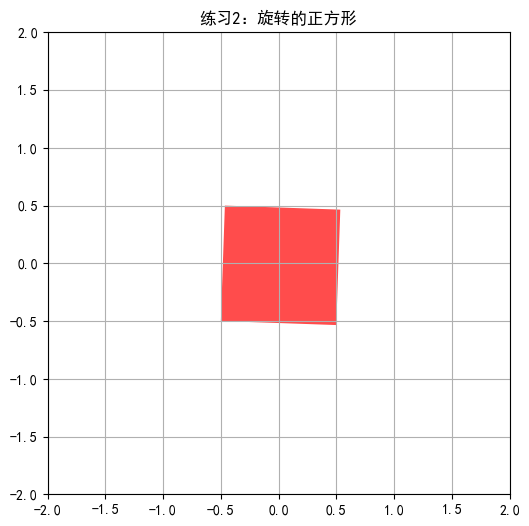

In [ ]:
# 2. 旋转的正方形
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文显示问题
plt.rcParams["axes.unicode_minus"] = False
# 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect("equal")  # 保持纵横比一致
ax.grid(True)  # 显示网格线

# 创建一个正方形
square = Rectangle((-0.5, -0.5), 1, 1, fc='red', alpha=0.7)
ax.add_patch(square)

def init():
    square.set_angle(0)  # 初始角度为0
    return [square]

def update(frame):
    square.set_angle(frame * 2)  # 每帧旋转2度
    return [square]

ani = FuncAnimation(fig, update, frames=180, init_func=init, blit=True, interval=30)
plt.title("练习2：旋转的正方形")
# plt.show()
ani.save("square.gif", writer="pillow", fps=30)

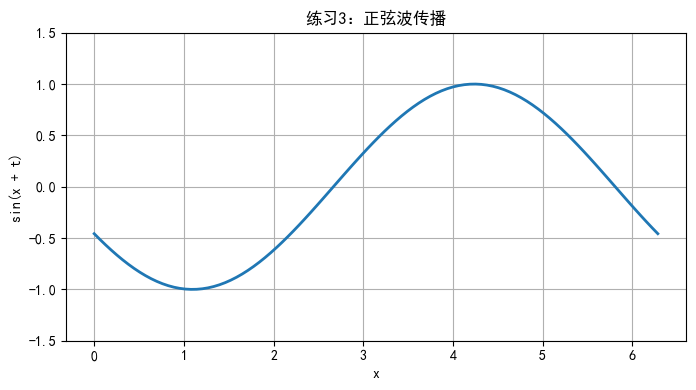

In [ ]:
# 3. 正弦波传播
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文显示问题
plt.rcParams["axes.unicode_minus"] = False
# 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_ylim(-1.5, 1.5)
ax.grid(True)  # 显示网格线

x = np.linspace(0, 2 * np.pi, 100)
line, = ax.plot(x, np.sin(x), lw=2)  # 绘制初始的正弦波


def init():
    line.set_ydata([np.nan] * len(x))  # 初始化数据为NaN，以便动画开始时从空白帧开始
    return line,


def update(frame):
    line.set_ydata(np.sin(x + frame * 0.1)) # 更新正弦波的相位
    return line,


ani = FuncAnimation(fig, update, frames=100, init_func=init, blit=True, interval=50)
plt.title("练习3：正弦波传播")
plt.xlabel("x")
plt.ylabel("sin(x + t)")\
# plt.show()
ani.save("sin(x).gif", writer="pillow", fps=30)

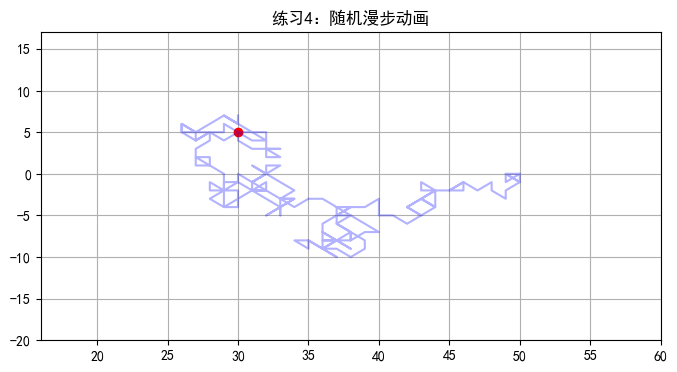

In [20]:
# 4. 随机漫步动画
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文显示问题
plt.rcParams["axes.unicode_minus"] = False
# 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, 100)
ax.set_ylim(-50, 50)
ax.grid(True)  # 显示网格线

# 初始化漫步者
walker, = ax.plot([], [], 'ro-', lw=2)  # 初始位置为(0,0)
path, = ax.plot([], [], 'b-', alpha=0.3)  # 初始路径为空
# 存储路径
x_data, y_data = [], []
def init():
    walker.set_data([], [])
    path.set_data([], [])
    return walker, path


def update(frame):
    # 随即移动
    dx = np.random.randint(-1, 2)
    dy = np.random.randint(-1, 2)
    if not x_data:
        x_data.append(50)
        y_data.append(0)
    else:
        x_data.append(x_data[-1] + dx)
        y_data.append(y_data[-1] + dy)
    walker.set_data([x_data[-1]], [y_data[-1]])
    path.set_data(x_data, y_data)
    # 自动调整视图
    ax.set_xlim(min(x_data) - 10, max(x_data) + 10)
    ax.set_ylim(min(y_data) - 10, max(y_data) + 10)
    return walker, path


ani = FuncAnimation(fig, update, frames=200, init_func=init, blit=True, interval=100)
plt.title("练习4：随机漫步动画")
# plt.show()
ani.save("walker.gif", writer="pillow", fps=30)